# BERT Notebook 3/3: Full Fine-tuning

Third and final part of the split project. All BERT weights are trainable here — the most
GPU- and time-intensive stage.

## Google Drive: mounting and paths

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Must match the path used in Notebooks 1 and 2
PROJECT_ROOT = '/content/drive/MyDrive/quora_dup_detection'
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
ARTIFACTS_DIR = os.path.join(PROJECT_ROOT, 'artifacts')
CHECKPOINTS_DIR = os.path.join(PROJECT_ROOT, 'checkpoints', 'full_finetune')

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)

print('DATA_DIR:       ', DATA_DIR)
print('ARTIFACTS_DIR:  ', ARTIFACTS_DIR)
print('CHECKPOINTS_DIR:', CHECKPOINTS_DIR)

Mounted at /content/drive
DATA_DIR:        /content/drive/MyDrive/quora_dup_detection/data
ARTIFACTS_DIR:   /content/drive/MyDrive/quora_dup_detection/artifacts
CHECKPOINTS_DIR: /content/drive/MyDrive/quora_dup_detection/checkpoints/full_finetune


## Imports and GPU check

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import pickle
warnings.filterwarnings('ignore')

import torch
from sklearn.metrics import log_loss, accuracy_score, f1_score, roc_auc_score

from datasets import Dataset, DatasetDict
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if device.type == 'cpu':
    print('WARNING: no GPU detected! Runtime -> Change runtime type -> GPU.')
else:
    print(torch.cuda.get_device_name(0))
    print(f'GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
Tesla T4
GPU memory: 15.6 GB


## Loading data from Google Drive

In [ ]:
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train_features_full.csv'))
val_df = pd.read_csv(os.path.join(DATA_DIR, 'val_features_full.csv'))
test_df = pd.read_csv(os.path.join(DATA_DIR, 'test_features_full.csv'))

print('Train shape:', train_df.shape)
print('Val shape:  ', val_df.shape)
print('Test shape: ', test_df.shape)

y_train = train_df['is_duplicate'].values
y_val = val_df['is_duplicate'].values
y_test = test_df['is_duplicate'].values

# results_train.csv / results_val.csv here are already updated by Notebooks 1 and 2
train_results_prev = pd.read_csv(os.path.join(DATA_DIR, 'results_train_p3.csv'))
val_results_prev = pd.read_csv(os.path.join(DATA_DIR, 'results_val_p3.csv'))

with open(os.path.join(DATA_DIR, 'val_predictions.pkl'), 'rb') as f:
    val_predictions = pickle.load(f)

# Sanity check: y_val here must match the split used when val_predictions.pkl was saved
assert np.array_equal(y_val, val_predictions['y_val']), \
    'y_val mismatch - train/val split differs from the one used to save val_predictions.pkl!'

val_results_prev

Train shape: (266488, 22)
Val shape:   (56941, 22)
Test shape:  (80858, 22)


,model,log_loss,f1,accuracy,roc_auc
0,Naive constant baseline,0.672988,0.000000,0.605065,0.500000
1,Threshold on word_share_jaccard,0.650177,0.655511,0.636659,0.722330
2,Logistic Regression (TF-IDF + features),0.525917,0.581317,0.711052,0.804393
3,XGBoost (TF-IDF),0.521324,0.523074,0.699988,0.797677
4,Logistic Regression (Word2Vec),0.531765,0.581234,0.700198,0.790394
5,XGBoost (Word2Vec),0.489078,0.630928,0.737992,0.829651
6,"Logistic Regression (BERT, frozen)",0.502090,0.636392,0.738027,0.826067
7,"XGBoost (BERT, frozen)",0.464834,0.669767,0.761806,0.852425
8,"BERT (fine-tuned, frozen base)",0.484529,0.699558,0.746755,0.829451


In [ ]:
# Inspect what's available in val_predictions.pkl so we can pick the right key
# for the Word2Vec+XGBoost probabilities used later in the ensembling section.
print('Keys available in val_predictions.pkl:', list(val_predictions.keys()))

Keys available in val_predictions.pkl: ['y_val', 'LogReg_TFIDF', 'XGBoost_TFIDF', 'LogReg_Word2Vec', 'XGBoost_Word2Vec']


## Loading the tokenizer and preparing the datasets

Tokenization is identical to Notebook 2, since both notebooks feed the same
`AutoModelForSequenceClassification` architecture.

In [ ]:
model_path = 'google-bert/bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_path)

id2label = {0: 'Not Duplicate', 1: 'Duplicate'}
label2id = {'Not Duplicate': 0, 'Duplicate': 1}

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
dataset_dict = DatasetDict({
    'train': Dataset.from_pandas(train_df[['question1', 'question2', 'is_duplicate']].reset_index(drop=True)),
    'val': Dataset.from_pandas(val_df[['question1', 'question2', 'is_duplicate']].reset_index(drop=True)),
    'test': Dataset.from_pandas(test_df[['question1', 'question2', 'is_duplicate']].reset_index(drop=True)),
})

def preprocess_function(examples):
    return tokenizer(
        examples["question1"],
        examples["question2"],
        truncation=True,
        max_length=64,
    )

tokenized_data = dataset_dict.map(preprocess_function, batched=True)
tokenized_data = tokenized_data.rename_column("is_duplicate", "labels")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(tokenized_data)

Map:   0%|          | 0/266488 [00:00<?, ? examples/s]

Map:   0%|          | 0/56941 [00:00<?, ? examples/s]

Map:   0%|          | 0/80858 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['question1', 'question2', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 266488
    })
    val: Dataset({
        features: ['question1', 'question2', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 56941
    })
    test: Dataset({
        features: ['question1', 'question2', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 80858
    })
})


In [ ]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    probabilities = np.exp(predictions) / np.exp(predictions).sum(-1, keepdims=True)
    positive_class_probs = probabilities[:, 1]
    predicted_classes = np.argmax(predictions, axis=1)

    return {
        'accuracy': accuracy_score(labels, predicted_classes),
        'auc': roc_auc_score(labels, positive_class_probs),
        'log_loss': log_loss(labels, positive_class_probs, labels=[0, 1]),
        'f1': f1_score(labels, predicted_classes),
    }


def add_result(results, model_name, y_true, y_proba, threshold=0.5):
    """Compute metrics for a model and append/update its row in the results table.

    If a row for `model_name` already exists (e.g. this cell was re-run after a previous
    experiment), it is replaced instead of duplicated - this keeps the results table
    reproducible no matter how many times cells are re-executed, which matters for a
    course project where the notebook may be re-run from a checkpoint."""
    y_pred = (y_proba >= threshold).astype(int)

    row = {
        'model': model_name,
        'log_loss': log_loss(y_true, y_proba),
        'f1': f1_score(y_true, y_pred),
        'accuracy': accuracy_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_proba)
    }

    results = results[results['model'] != model_name].reset_index(drop=True)
    results.loc[len(results)] = row
    display(results)

    return results

## Choosing the number of epochs

**This decision is based on evidence from an earlier run of this notebook with
`num_epochs_full=2`.** The per-epoch training log looked like this:

| Epoch | Training Loss | Validation Loss (log_loss) | Val F1 |
|---|---|---|---|
| 1 | 0.300 | **0.4195** | 0.768 |
| 2 | 0.183 | **0.4667** | 0.779 |

Training loss keeps decreasing (0.300 → 0.183), while validation loss **increases** (0.4195 → 0.4667) between epoch 1 and epoch 2. This is a overfitting signature: the model keeps memorizing the training set, but that no longer generalizes to unseen validation examples past epoch 1.

However, training a second epoch that just gets discarded wastes real GPU time (~45 minutes in the earlier run). We therefore fix **`num_epochs_full=1`** for this dataset size: it reproduces the same result as before while roughly halving training time.

## BERT Full Fine-tuning

All parameters of the model are trainable (nothing frozen this time).

In [ ]:
model_full_ft = AutoModelForSequenceClassification.from_pretrained(
    model_path, num_labels=2, id2label=id2label, label2id=label2id
)

trainable_params = sum(p.numel() for p in model_full_ft.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_full_ft.parameters())
print(f'Training {trainable_params:,} out of {total_params:,} parameters ({trainable_params/total_params*100:.1f}%)')

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training 109,483,778 out of 109,483,778 parameters (100.0%)


In [ ]:
lr_full = 2e-5
batch_size_full = 32
num_epochs_full = 1  # reduced from 2 - see the "Choosing the number of epochs" section above

training_args_full = TrainingArguments(
    output_dir=CHECKPOINTS_DIR,
    learning_rate=lr_full,
    per_device_train_batch_size=batch_size_full,
    per_device_eval_batch_size=batch_size_full,
    num_train_epochs=num_epochs_full,
    logging_strategy='epoch',
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model='log_loss',
    greater_is_better=False,
    report_to=[],
)

In [ ]:
%%time
trainer_full = Trainer(
    model=model_full_ft,
    args=training_args_full,
    train_dataset=tokenized_data['train'],
    eval_dataset=tokenized_data['val'],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer_full.train()

Epoch,Training Loss,Validation Loss,Accuracy,Auc,Log Loss,F1,Runtime,Samples Per Second,Steps Per Second
1,0.299810,0.408447,0.838359,0.917313,0.408447,0.783425,210.875200,270.022000,8.441000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

CPU times: user 47min 55s, sys: 8.65 s, total: 48min 3s
Wall time: 49min 42s


TrainOutput(global_step=8328, training_loss=0.2998100522615724, metrics={'train_runtime': 2981.1242, 'train_samples_per_second': 89.392, 'train_steps_per_second': 2.794, 'total_flos': 8194236152596320.0, 'train_loss': 0.2998100522615724, 'epoch': 1.0})

## Evaluation on train and validation

In [12]:
%%time
train_preds_full = trainer_full.predict(tokenized_data['train'])
train_proba_full = np.exp(train_preds_full.predictions)
train_proba_full /= train_proba_full.sum(axis=1, keepdims=True)
train_proba_full = train_proba_full[:, 1]

val_preds_full = trainer_full.predict(tokenized_data['val'])
val_proba_full = np.exp(val_preds_full.predictions)
val_proba_full /= val_proba_full.sum(axis=1, keepdims=True)
val_proba_full = val_proba_full[:, 1]

CPU times: user 19min 36s, sys: 5.5 s, total: 19min 41s
Wall time: 20min 2s


In [13]:
print('='*30+'Train'+'='*30)
train_results = add_result(train_results_prev, 'BERT (fine-tuned, full)', y_train, train_proba_full)

print('='*30+'Validation'+'='*30)
val_results = add_result(val_results_prev, 'BERT (fine-tuned, full)', y_val, val_proba_full)

==============================Train==============================


,model,log_loss,f1,accuracy,roc_auc
0,Naive constant baseline,0.655518,0.000000,0.636299,0.500000
1,Threshold on word_share_jaccard,0.648484,0.632415,0.625364,0.732250
2,Logistic Regression (TF-IDF + features),0.426158,0.697843,0.790347,0.873204
3,XGBoost (TF-IDF),0.448985,0.653174,0.774545,0.858775
4,Logistic Regression (Word2Vec),0.492585,0.623092,0.735035,0.815719
5,XGBoost (Word2Vec),0.360521,0.780661,0.842781,0.922449
6,"Logistic Regression (BERT, frozen)",0.425666,0.705789,0.789011,0.870666
7,"XGBoost (BERT, frozen)",0.325103,0.808335,0.860969,0.938558
8,"BERT (fine-tuned, frozen base)",0.433724,0.739224,0.783773,0.875156
9,"BERT (fine-tuned, full)",0.191815,0.897757,0.923888,0.975069


==============================Validation==============================


,model,log_loss,f1,accuracy,roc_auc
0,Naive constant baseline,0.672988,0.000000,0.605065,0.500000
1,Threshold on word_share_jaccard,0.650177,0.655511,0.636659,0.722330
2,Logistic Regression (TF-IDF + features),0.525917,0.581317,0.711052,0.804393
3,XGBoost (TF-IDF),0.521324,0.523074,0.699988,0.797677
4,Logistic Regression (Word2Vec),0.531765,0.581234,0.700198,0.790394
5,XGBoost (Word2Vec),0.489078,0.630928,0.737992,0.829651
6,"Logistic Regression (BERT, frozen)",0.502090,0.636392,0.738027,0.826067
7,"XGBoost (BERT, frozen)",0.464834,0.669767,0.761806,0.852425
8,"BERT (fine-tuned, frozen base)",0.484529,0.699558,0.746755,0.829451
9,"BERT (fine-tuned, full)",0.408447,0.783425,0.838359,0.917313


**Conclusion:** Full fine-tuning clearly beats every other model tried so far in this project.

## Decision threshold tuning

So far every model in this project has used a fixed decision threshold of 0.5 to convert predicted probabilities into class labels. That threshold is only optimal for F1 when the classes are exactly balanced and false positives/false negatives are equally costly.

We scan a grid of thresholds on the **validation set** and pick the one that maximizes F1, then reuse that same threshold later on the test set.

Best threshold on validation: 0.26 (F1 = 0.8063)
F1 at default threshold 0.50: 0.7834


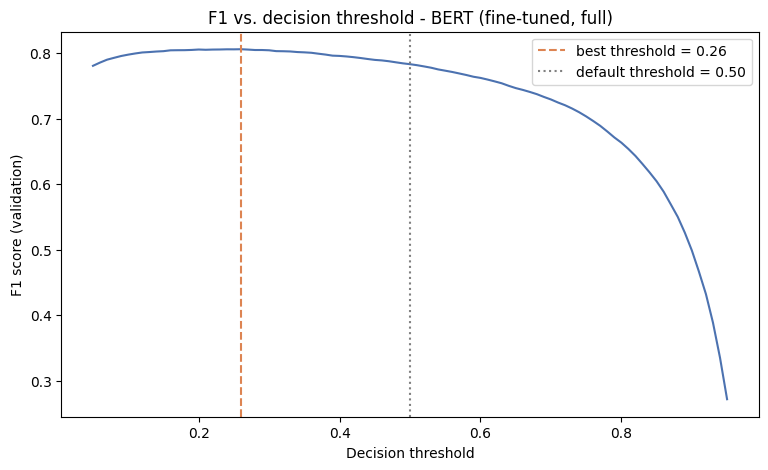

In [14]:
thresholds = np.arange(0.05, 0.96, 0.01)
f1_scores = [f1_score(y_val, (val_proba_full >= t).astype(int)) for t in thresholds]

best_idx = int(np.argmax(f1_scores))
best_threshold = thresholds[best_idx]
best_f1_at_threshold = f1_scores[best_idx]

print(f'Best threshold on validation: {best_threshold:.2f} (F1 = {best_f1_at_threshold:.4f})')
print(f'F1 at default threshold 0.50: {f1_score(y_val, (val_proba_full >= 0.5).astype(int)):.4f}')

plt.figure(figsize=(9, 5))
plt.plot(thresholds, f1_scores, color='#4C72B0')
plt.axvline(best_threshold, color='#DD8452', linestyle='--', label=f'best threshold = {best_threshold:.2f}')
plt.axvline(0.5, color='gray', linestyle=':', label='default threshold = 0.50')
plt.xlabel('Decision threshold')
plt.ylabel('F1 score (validation)')
plt.title('F1 vs. decision threshold - BERT (fine-tuned, full)')
plt.legend()
plt.show()

In [15]:
print('='*30+'Validation (tuned threshold)'+'='*30)
val_results = add_result(
    val_results,
    'BERT (fine-tuned, full, tuned threshold)',
    y_val,
    val_proba_full,
    threshold=best_threshold
)

==============================Validation (tuned threshold)==============================


,model,log_loss,f1,accuracy,roc_auc
0,Naive constant baseline,0.672988,0.000000,0.605065,0.500000
1,Threshold on word_share_jaccard,0.650177,0.655511,0.636659,0.722330
2,Logistic Regression (TF-IDF + features),0.525917,0.581317,0.711052,0.804393
3,XGBoost (TF-IDF),0.521324,0.523074,0.699988,0.797677
4,Logistic Regression (Word2Vec),0.531765,0.581234,0.700198,0.790394
5,XGBoost (Word2Vec),0.489078,0.630928,0.737992,0.829651
6,"Logistic Regression (BERT, frozen)",0.502090,0.636392,0.738027,0.826067
7,"XGBoost (BERT, frozen)",0.464834,0.669767,0.761806,0.852425
8,"BERT (fine-tuned, frozen base)",0.484529,0.699558,0.746755,0.829451
9,"BERT (fine-tuned, full)",0.408447,0.783425,0.838359,0.917313


**Conclusion:** tuning the decision threshold (0.26 instead of 0.5) gave a further, "free" boost to F1 (0.783 → 0.806) with no retraining needed, since it only affects how probabilities are converted into labels.

## Ensembling: BERT (fine-tuned, full) + XGBoost (Word2Vec)

The two models make errors in different ways: BERT captures deep contextual/semantic similarity, while the Word2Vec+XGBoost model relies on shallow lexical/statistical similarity features.

We only have saved validation probabilities for the Word2Vec+XGBoost model (from `val_predictions.pkl`, produced in the very first notebook).

In [20]:
w2v_xgb_key = 'XGBoost_Word2Vec'

if w2v_xgb_key not in val_predictions:
    raise KeyError(
        f"'{w2v_xgb_key}' not found in val_predictions.pkl. "
        f"Available keys: {list(val_predictions.keys())}"
    )

val_proba_w2v_xgb = np.asarray(val_predictions[w2v_xgb_key])
assert val_proba_w2v_xgb.shape == y_val.shape, \
    f"Shape mismatch: val_proba_w2v_xgb {val_proba_w2v_xgb.shape} vs y_val {y_val.shape}"

print('Shape:', val_proba_w2v_xgb.shape)

Shape: (56941,)


In [21]:
# Simple averaging ensemble - both models contribute equally.
val_proba_ensemble = 0.5 * val_proba_full + 0.5 * val_proba_w2v_xgb

print('='*30+'Validation (ensemble)'+'='*30)
val_results = add_result(
    val_results,
    'Ensemble: BERT (full) + XGBoost (Word2Vec)',
    y_val,
    val_proba_ensemble
)

==============================Validation (ensemble)==============================


,model,log_loss,f1,accuracy,roc_auc
0,Naive constant baseline,0.672988,0.000000,0.605065,0.500000
1,Threshold on word_share_jaccard,0.650177,0.655511,0.636659,0.722330
2,Logistic Regression (TF-IDF + features),0.525917,0.581317,0.711052,0.804393
3,XGBoost (TF-IDF),0.521324,0.523074,0.699988,0.797677
4,Logistic Regression (Word2Vec),0.531765,0.581234,0.700198,0.790394
5,XGBoost (Word2Vec),0.489078,0.630928,0.737992,0.829651
6,"Logistic Regression (BERT, frozen)",0.502090,0.636392,0.738027,0.826067
7,"XGBoost (BERT, frozen)",0.464834,0.669767,0.761806,0.852425
8,"BERT (fine-tuned, frozen base)",0.484529,0.699558,0.746755,0.829451
9,"BERT (fine-tuned, full)",0.408447,0.783425,0.838359,0.917313


**Conclusion:** Combining BERT with XGBoost (Word2Vec) improves log_loss further (0.388 vs. 0.408) — the best of any model — but at the cost of F1 (0.768 vs. 0.806) and ROC-AUC (0.908 vs. 0.917) compared to standalone fine-tuned BERT. Since F1 and ROC-AUC better reflect real classification performance for this task, the ensemble is not chosen as the final model — BERT (fine-tuned, full) with a tuned threshold remains the best model overall.

As an extra variant, we could also try a weighted average (e.g. `0.7 * val_proba_full + 0.3 * val_proba_w2v_xgb`, weighting the stronger model more) for further experiments.

## Final test evaluation

We evaluate the standalone BERT (fine-tuned, full) model on `test.csv`, using the threshold tuned on validation.

In [22]:
%%time
test_preds_full = trainer_full.predict(tokenized_data['test'])
test_proba_full = np.exp(test_preds_full.predictions)
test_proba_full /= test_proba_full.sum(axis=1, keepdims=True)
test_proba_full = test_proba_full[:, 1]

test_preds_default = (test_proba_full >= 0.5).astype(int)
test_preds_tuned = (test_proba_full >= best_threshold).astype(int)

print(f'Test log loss: {log_loss(y_test, test_proba_full):.4f}')
print(f'Test ROC-AUC:  {roc_auc_score(y_test, test_proba_full):.4f}')
print(f'Test F1 (threshold=0.50):            {f1_score(y_test, test_preds_default):.4f}')
print(f'Test F1 (threshold={best_threshold:.2f}, tuned on val): {f1_score(y_test, test_preds_tuned):.4f}')


Test log loss: 0.2792
Test ROC-AUC:  0.9511
Test F1 (threshold=0.50):            0.8430
Test F1 (threshold=0.26, tuned on val): 0.8430
CPU times: user 4min 45s, sys: 1.15 s, total: 4min 47s
Wall time: 5min 3s


## Saving updated metric tables to Drive

This is the last notebook in the series, so `results_train.csv` / `results_val.csv` on Drive
now contain the full comparison across all models from all three notebooks, including the
threshold-tuned and ensembled variants.


In [23]:
train_results.to_csv(os.path.join(DATA_DIR, 'results_train.csv'), index=False)
val_results.to_csv(os.path.join(DATA_DIR, 'results_val.csv'), index=False)
print('Updated results_train.csv / results_val.csv saved to Drive.')

Updated results_train.csv / results_val.csv saved to Drive.


## Error analysis (best model: BERT full fine-tune, tuned threshold, val split)

In [24]:
error_df = val_df[['question1', 'question2']].copy()
error_df['is_duplicate'] = y_val
error_df['pred_proba'] = val_proba_full
error_df['pred_label'] = (val_proba_full >= best_threshold).astype(int)

conditions = [
    (error_df['is_duplicate'] == 1) & (error_df['pred_label'] == 1),
    (error_df['is_duplicate'] == 0) & (error_df['pred_label'] == 0),
    (error_df['is_duplicate'] == 1) & (error_df['pred_label'] == 0),
    (error_df['is_duplicate'] == 0) & (error_df['pred_label'] == 1),
]
choices = ['true_positive', 'true_negative', 'false_negative', 'false_positive']
error_df['error_type'] = np.select(conditions, choices, default='unknown')

print(error_df['error_type'].value_counts())

error_type
true_negative     29019
true_positive     18859
false_positive     5434
false_negative     3629
Name: count, dtype: int64


In [25]:
print('Examples of FALSE NEGATIVE (actual duplicate that the model missed):')
error_df[error_df.error_type == 'false_negative'][['question1', 'question2', 'pred_proba']].sample(
    min(10, (error_df.error_type == 'false_negative').sum()), random_state=1
)

Examples of FALSE NEGATIVE (actual duplicate that the model missed):


,question1,question2,pred_proba
1711,How can you rapidly lose weight in 14days?,How can I lose weight ?,0.209824
8844,What are the safety precautions on handling sh...,What are the safety precautions on handling sh...,0.003935
33975,How do I get funding for my web based startup ...,How can you get VCs to fund you if you just ha...,0.228561
15101,"In a plant cell, what is the function of the v...","Within a cell, what is the function of the vac...",0.210227
20060,"I like a girl who I used to be friends with, a...",Dating Advice: I really like a girl but she al...,0.206608
7081,Is it racist to say that you don't want to dat...,Are you a racist if you only date within your ...,0.175971
27876,"If you have just passed your CFA Level I, what...",What are the available job opportunities after...,0.235389
49179,How can the drive from Edmonton to Auckland be...,How can the drive from Edmonton to Auckland be...,0.002949
25741,How possible is it to get pregnant one day aft...,Can you get pregnant 16 days after your period?,0.144922
15313,Which is the best job in india?,Which is the best job in india in modern genre...,0.090163


In [26]:
print('Examples of FALSE POSITIVE (predicted duplicate, but actually not):')
error_df[error_df.error_type == 'false_positive'][['question1', 'question2', 'pred_proba']].sample(
    min(10, (error_df.error_type == 'false_positive').sum()), random_state=1
)

Examples of FALSE POSITIVE (predicted duplicate, but actually not):


,question1,question2,pred_proba
26335,Is ON whey protein good?,Is whey protein good?,0.472280
42042,Would you consider Trump as a hypocrite?,Do you consider Trump a pervert?,0.866155
35360,What was there when there was nothing?,What was there when nothing was there?,0.925217
44016,When do the college football rankings come out?,How are college football rankings calculated?,0.489365
2167,What are some of the most exotic foods?,What is the most exotic food you have ever had?,0.398472
15146,How is the best way to get very good clients b...,What's the best way/site to hire a freelance g...,0.675950
30521,What Jimmy Wales think about Quora?,"What does Jimmy Wales think of all the ""What d...",0.856685
10839,What are some good history books to read?,What is the best book to read about history?,0.757908
42333,How can the population of India be controlled?,Do you think that the population of India shou...,0.716807
22637,What does an avocado taste like?,What does avocado oil taste like and how is it...,0.605186


**Conclusion:** The model most often struggles in two situations:

1. When one question is much more specific than the other (e.g., "How can you rapidly lose weight in 14days?" vs. just "How can I lose weight?") 

2. The model sometimes latches onto sentence structure while ignoring the one key word that completely changes the meaning: for the pair "Would you consider Trump a hypocrite?" and "Do you consider Trump a pervert?", it predicted an 87% chance of being duplicates.